로드된 컬럼: ['행정구역별(시군구)_행정구역별(시군구)', '합계', '합계.1', '합계.2', '15세미만', '15세미만.1', '15세미만.2', '15~19세', '15~19세.1', '15~19세.2', '20~24세', '20~24세.1', '20~24세.2', '25~29세', '25~29세.1', '25~29세.2', '30~34세', '30~34세.1', '30~34세.2', '35~39세', '35~39세.1', '35~39세.2', '40~44세', '40~44세.1', '40~44세.2', '45~49세', '45~49세.1', '45~49세.2', '50~54세', '50~54세.1', '50~54세.2', '55~59세', '55~59세.1', '55~59세.2', '60~64세', '60~64세.1', '60~64세.2', '65~69세', '65~69세.1', '65~69세.2', '70~74세', '70~74세.1', '70~74세.2', '75~79세', '75~79세.1', '75~79세.2', '80~84세', '80~84세.1', '80~84세.2', '85세이상', '85세이상.1', '85세이상.2', '15~64세', '15~64세.1', '15~64세.2', '65세이상', '65세이상.1', '65세이상.2']

[1] 2015년 이후 남자 및 여자 일반가구원 통계
성별 전체 데이터를 찾지 못했습니다. 컬럼명을 확인하세요: Index(['행정구역별(시군구)_행정구역별(시군구)', '합계', '합계.1', '합계.2', '15세미만', '15세미만.1',
       '15세미만.2', '15~19세', '15~19세.1', '15~19세.2', '20~24세', '20~24세.1',
       '20~24세.2', '25~29세', '25~29세.1', '25~29세.2', '30~34세', '30~34세.1',
       '30~34세.2', '35~39세', '35~39세.1', '35~39세.2', '

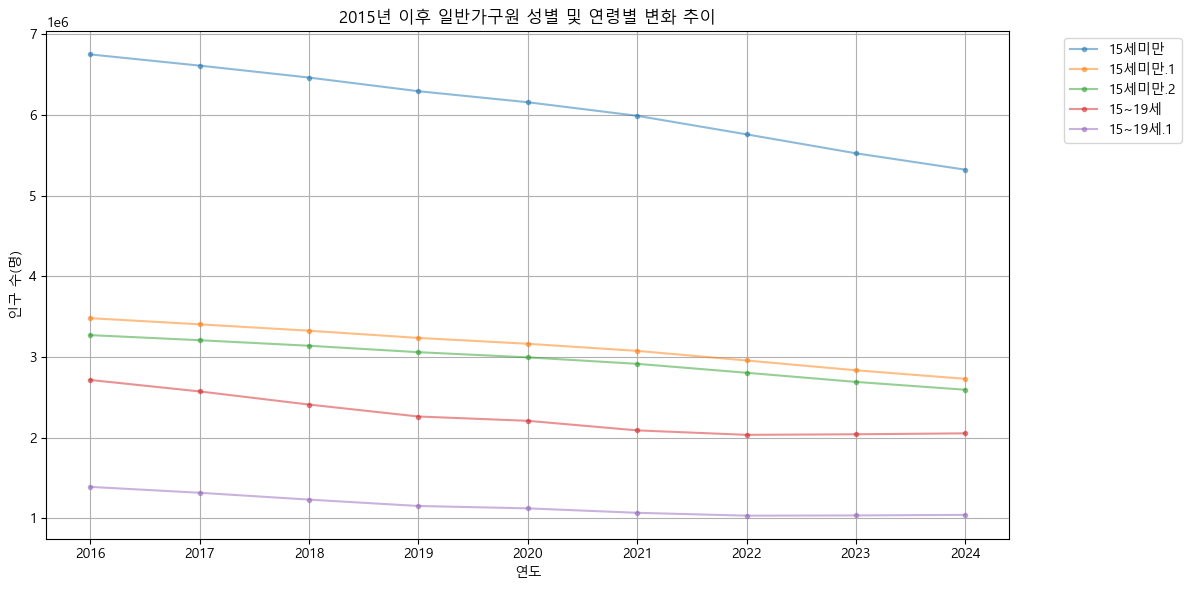

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
# 운영체제에 맞게 폰트 이름을 변경해서 사용하세요.
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

def load_and_clean_kosis_data(filename):
    """
    KOSIS 데이터를 읽고 헤더를 정리하는 함수
    """
    try:
        # KOSIS CSV는 보통 cp949 인코딩입니다.
        # 헤더가 2줄(대분류, 소분류)일 가능성이 높으므로 header=[0, 1] 옵션 사용
        df = pd.read_csv(filename, encoding='cp949', header=[0, 1], index_col=0)
    except FileNotFoundError:
        print(f"Error: '{filename}' 파일을 찾을 수 없습니다.")
        return None
    except Exception as e:
        # header 옵션 없이 다시 시도 (헤더가 1줄인 경우 대비)
        try:
            df = pd.read_csv(filename, encoding='cp949', index_col=0)
        except:
            print(f"파일 읽기 오류: {e}")
            return None

    # 1. 불필요한 '행정구역별' 컬럼 제거 (데이터에 포함되어 있다면)
    # 다중 인덱스 컬럼일 경우 처리
    if '행정구역별' in df.columns.get_level_values(0):
        df = df.drop(columns=['행정구역별'], level=0)
    elif '행정구역별' in df.columns: # 단일 인덱스일 경우
         df = df.drop(columns=['행정구역별'])

    # 2. 컬럼 이름 단순화 (멀티 인덱스를 하나의 이름으로 합침)
    # 예: ('일반가구원', '남자') -> '남자'
    # 예: ('15세미만', '계') -> '15세미만_계'
    new_columns = []
    for col in df.columns:
        if isinstance(col, tuple):
            # 상위 분류(일반가구원 등)가 너무 길면 제외하고 하위 분류만 사용하거나 합침
            # 여기서는 명확성을 위해 두 개를 합칩니다.
            c1 = str(col[0]).replace('일반가구원', '').strip() # '일반가구원' 글자 제거
            c2 = str(col[1]).strip()
            
            if c1 and c2:
                name = f"{c1}_{c2}"
            else:
                name = c2 if c2 else c1
            new_columns.append(name)
        else:
            new_columns.append(str(col))
            
    df.columns = new_columns
    
    # 3. 데이터 수치형 변환 (콤마 제거)
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    return df

def analyze_and_visualize(df):
    """
    데이터 분석 및 시각화
    """
    # 1. 남자, 여자 전체 데이터 추출
    # 컬럼명에 '남자', '여자'가 포함되고 특정 연령대('세')가 없는 컬럼이 전체 성별 데이터일 확률 높음
    male_col = [c for c in df.columns if '남자' in c and '세' not in c]
    female_col = [c for c in df.columns if '여자' in c and '세' not in c]
    
    # 리스트에서 첫 번째 항목 선택 (보통 '합계_남자' 또는 '계_남자' 꼴임)
    m_col = male_col[0] if male_col else None
    f_col = female_col[0] if female_col else None

    print("\n[1] 2015년 이후 남자 및 여자 일반가구원 통계")
    if m_col and f_col:
        print(df[[m_col, f_col]])
    else:
        print("성별 전체 데이터를 찾지 못했습니다. 컬럼명을 확인하세요:", df.columns)

    # 2. 연령별 데이터 추출
    # '세'가 들어간 컬럼들 추출 (예: '15세미만_계', '15~19세_계' 등)
    # 성별로 나뉜 것('남자', '여자')을 제외하고 '계' 또는 합계인 것만 추려낼 수도 있음
    age_cols = [c for c in df.columns if '세' in c and ('계' in c or '합계' in c or ('남자' not in c and '여자' not in c))]
    
    print("\n[2] 2015년 이후 연령별 일반가구원 통계")
    if age_cols:
        print(df[age_cols].head())
    else:
        print("연령별 데이터를 찾지 못했습니다. 컬럼명을 확인하세요:", df.columns)

    # 3. 그래프 그리기 (꺾은선 그래프)
    plt.figure(figsize=(12, 6))
    
    # 성별 그래프
    if m_col and f_col:
        plt.plot(df.index, df[m_col], label='남자', marker='o', linestyle='-')
        plt.plot(df.index, df[f_col], label='여자', marker='s', linestyle='--')

    # 연령별 그래프 (너무 많으면 주요 항목만)
    for col in age_cols[:5]: # 앞의 5개 연령대만 예시로 출력
        plt.plot(df.index, df[col], label=col, marker='.', alpha=0.5)

    plt.title('2015년 이후 일반가구원 성별 및 연령별 변화 추이')
    plt.xlabel('연도')
    plt.ylabel('인구 수(명)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 실행
if __name__ == "__main__":
    # 다운로드 받은 파일명 입력
    dataset = load_and_clean_kosis_data('population.csv')
    
    if dataset is not None:
        # 데이터가 잘 읽혔는지 확인용 출력
        print("로드된 컬럼:", dataset.columns.tolist())
        analyze_and_visualize(dataset)